# Qseek Catalog Validation and Comparison of the Original and Transfer-Learning Detection Models

**Purpose.** This notebook performs a full validation of two automated
seismic detection catalogs produced by Qseek -- the *original* model
and a *transfer-learning* model with `SimpleStationCorrection` -- and
builds the quantitative evidence needed to answer the central question
of this analysis:

> The original model detects more events than the transfer-learning
> model. Does that make the original catalog better, or does the
> transfer model produce a smaller but higher quality (more reliable)
> catalog?

**Approach.** Raw event count is not, by itself, a measure of catalog
quality. A larger catalog can contain more real microseismicity, more
false/weak detections, or both. This notebook therefore:

1.  Validates and cleans both catalogs and the station metadata
    (structural QC).
2.  Applies an explicit, reproducible quality-control (QC) scheme to
    every event (RMS residual, station/pick support, semblance,
    azimuthal coverage, location uncertainty, distance to the
    search-volume border, depth plausibility, magnitude error).
3.  Compares the two catalogs statistically as independent populations
    (QC pass rates, summary statistics, distributions, maps, depth
    sections, magnitude-frequency behaviour, monthly rates) -- **no
    event-by-event matching between the two catalogs is performed.**
    Each catalog is judged on its own merits.
4.  Automatically generates a written, data-driven interpretation and
    all figures/tables in publication-ready form (PNG + vector PDF) for
    direct use in the thesis discussion section.

**Note on scope.** This notebook deliberately does *not* attempt to
spatio-temporally match individual events between the original and
transfer catalogs. The argument made here is a distributional one: if
the transfer catalog is systematically better on independent quality
indicators (lower RMS, lower location uncertainty, higher semblance,
better azimuthal coverage, etc.) while also having fewer events, this
is evidence that the reduction in event count reflects a more
conservative, higher-precision detector rather than a loss of genuine
signal. It is not, by itself, proof that every specific event lost was
a false detection – that stronger, event-level claim would require
matching (or an independent reference catalog), which is outside the
scope of this analysis.

**How to use this notebook**

1.  Place your CSV files next to this notebook, or set full paths in the
    **Configuration** cell below.
2.  Run the cells in order, top to bottom. Every cell can be re-run
    independently after the data has been loaded and cleaned (cells are
    debuggable in isolation).
3.  All tables and figures are written to `OUTPUT_DIR` (default:
    `qseek_validation_outputs/`), and figures are saved both as `.png`
    (for quick viewing) and `.pdf` (vector, for direct inclusion in
    LaTeX/Word theses).

## 1. Configuration

Edit the paths and thresholds below. Everything downstream depends only
on this cell, so it is safe to change these values and re-run the whole
notebook.

**On QC thresholds:** leave a threshold as `None` if you are not yet
sure of the correct value/units for your Qseek configuration. Undefined
thresholds are simply not applied (the corresponding QC flag is always
`True`), so the pipeline runs end-to-end even before every threshold has
been tuned. Document whichever thresholds you do set in your thesis
methods section -- the values below are placeholders you should confirm
against your own Qseek run configuration.

In [1]:

# =========================
# 1. CONFIGURATION
# =========================

from pathlib import Path

# ---- Required / optional input files ----------------------------------------------------
ORIGINAL_DETECTIONS_CSV = Path("qseek/klingenthal-original/csv/detections.csv")

# Set to None if you only have one detection catalog.
TRANSFER_DETECTIONS_CSV = Path("qseek/klingenthal-ssst.bak-2026-06-19T162808/csv/detections.csv")

# Required station metadata file.
STATIONS_CSV = Path("qseek/klingenthal-original/csv/stations.csv")

# Optional independent reference catalog (e.g. WEBNET). Set to None if not available.
REFERENCE_CATALOG_CSV = None

OUTPUT_DIR = Path("qseek_validation_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ---- Study period ------------------------------------------------------------------------
# Restrict analysis to a single study year. Set to None to keep all years present in the data.
STUDY_YEAR = None

# ---- Study region -------------------------------------------------------------------------
# Manual region bounding box. Set to None to derive a station-based bounding box with margin.
# Example: MANUAL_BBOX = {"lat_min": 49.8, "lat_max": 50.6, "lon_min": 11.7, "lon_max": 13.2}
MANUAL_BBOX = None
STATION_BBOX_MARGIN_DEG = 0.5

# ---- Quality-control thresholds ------------------------------------------------------------
# Keep thresholds explicit and report the ones you use in your thesis methods section.
# Use None to skip a threshold (the pipeline still runs; the flag is then always True).
QC_THRESHOLDS = {
    "min_n_stations": 4,
    "min_n_picks": 5,
    "max_rms": None,                      # seconds, if applicable
    "max_uncertainty_horizontal": None,   # km (check your Qseek units)
    "max_uncertainty_vertical": None,     # km
    "min_distance_border": None,          # same unit as distance_border column
    "min_semblance": None,                # 0-1 scale typically
    "min_azimuthal_coverage": None,       # degrees, larger = better
    "min_depth": -2,                      # km
    "max_depth": 40,                      # km
    "max_ml_error": None,
}

# ---- Catalog matching parameters (original vs transfer, and vs reference) -----------------
MATCH_TIME_WINDOW_SECONDS = 5
MATCH_DISTANCE_WINDOW_KM = 5

# ---- Plot / output settings ----------------------------------------------------------------
MAX_POINTS_ON_MAP = 20000
FIG_DPI = 300              # thesis-quality raster resolution
SAVE_VECTOR_PDF = True     # also save each figure as a vector PDF for LaTeX/Word inclusion

print("Configuration loaded.")
print("Output folder:", OUTPUT_DIR.resolve())

Configuration loaded.
Output folder: /storage/vast-gfz-hpc-01/home/khuzaima/project/thesis_seismology/qseek_validation_outputs


## 2. Imports and thesis plot style

A single, consistent visual style is applied to every figure in this
notebook (font, colours, resolution) so that all exported plots look
coherent when placed side by side in a thesis chapter. The two catalogs
are always plotted with the same two colours throughout: **original =
steel blue**, **transfer = dark orange**.

In [2]:

# =========================
# 2. IMPORTS
# =========================

import re
import math
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# ---- Thesis-style plot settings -----------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": FIG_DPI,
    "font.size": 11,
    "font.family": "serif",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
    "savefig.bbox": "tight",
})

# Fixed colour scheme used consistently across every figure in the notebook.
CATALOG_COLORS = {
    "original": "#2E6F95",                     # steel blue
    "transfer_station_correction": "#D9782D",  # dark orange
    "reference": "#4C9A5B",                    # muted green
}

print("Notebook ready.")
print("Output folder:", OUTPUT_DIR.resolve())

Notebook ready.
Output folder: /storage/vast-gfz-hpc-01/home/khuzaima/project/thesis_seismology/qseek_validation_outputs


## 3. Helper functions

This section defines every reusable function used later in the notebook,
including the **robust time parser** (`parse_qseek_time`), which
transparently handles ISO datetime strings and UNIX epoch timestamps in
seconds / milliseconds / microseconds / nanoseconds. Using the robust
parser from the start avoids the empty monthly-event-rate error that
occurs when the `time` column is not recognised.

In [3]:

# =========================
# 3. HELPER FUNCTIONS
# =========================

def normalize_colname(col):
    """Convert messy / inconsistent column names to safe snake_case names."""
    col = str(col).strip()
    col = col.replace("ML-webnet-western-bohemia", "ml_webnet_western_bohemia")
    col = col.replace("ML-error-webnet-western-bohemia", "ml_error_webnet_western_bohemia")
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col)
    col = col.strip("_").lower()
    return col


def normalize_columns(df):
    out = df.copy()
    out.columns = [normalize_colname(c) for c in out.columns]
    return out


def read_csv_auto(path):
    """Read a CSV with automatic separator detection. Returns None for a None path."""
    if path is None:
        return None
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")
    return pd.read_csv(path, sep=None, engine="python")


def to_numeric_safe(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def extract_point_from_wkt(wkt_value):
    """Extract (lon, lat) from a WKT POINT string such as 'POINT (12.3 50.1)'."""
    if pd.isna(wkt_value):
        return np.nan, np.nan
    s = str(wkt_value).strip()
    m = re.search(r"POINT\s*\(?\s*([-+]?\d+(?:\.\d+)?)\s+([-+]?\d+(?:\.\d+)?)", s, flags=re.I)
    if not m:
        return np.nan, np.nan
    return float(m.group(1)), float(m.group(2))


def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized haversine great-circle distance in kilometres."""
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def derive_bbox_from_stations(stations, margin_deg=0.5):
    return {
        "lat_min": stations["latitude"].min() - margin_deg,
        "lat_max": stations["latitude"].max() + margin_deg,
        "lon_min": stations["longitude"].min() - margin_deg,
        "lon_max": stations["longitude"].max() + margin_deg,
    }


def apply_bbox_flag(df, bbox):
    return (
        df["lat"].between(bbox["lat_min"], bbox["lat_max"], inclusive="both")
        & df["lon"].between(bbox["lon_min"], bbox["lon_max"], inclusive="both")
    )


def savefig(name):
    """Save the current figure as PNG (and optionally vector PDF) and display it."""
    plt.tight_layout()
    png_path = OUTPUT_DIR / f"{name}.png"
    plt.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
    if SAVE_VECTOR_PDF:
        pdf_path = OUTPUT_DIR / f"{name}.pdf"
        plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", png_path.name, "(+ .pdf)" if SAVE_VECTOR_PDF else "")


def missing_summary(df):
    return (
        df.isna().sum().rename("missing_count").to_frame()
        .assign(missing_percent=lambda x: 100 * x["missing_count"] / len(df))
        .sort_values("missing_count", ascending=False)
    )


def numeric_summary(df, cols):
    existing = [c for c in cols if c in df.columns]
    if not existing:
        return pd.DataFrame()
    return df[existing].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T


def parse_qseek_time(series):
    """
    Robust parser for Qseek / catalog time columns. Handles:
      - ISO datetime strings, e.g. '2025-01-01T12:34:56.123Z'
      - plain datetime strings, e.g. '2025-01-01 12:34:56'
      - UNIX epoch in seconds, milliseconds, microseconds, or nanoseconds

    Falling back to numeric epoch parsing only happens if ordinary datetime
    parsing fails for more than half the values, which is what previously
    caused an all-NaT 'time' column and the empty monthly event-rate error.
    """
    parsed = pd.to_datetime(series, errors="coerce", utc=True)
    failed_ratio = parsed.isna().mean()

    if failed_ratio > 0.5:
        numeric = pd.to_numeric(series, errors="coerce")
        if numeric.notna().sum() > 0:
            median_val = numeric.dropna().median()
            if median_val > 1e17:
                unit = "ns"
            elif median_val > 1e14:
                unit = "us"
            elif median_val > 1e11:
                unit = "ms"
            elif median_val > 1e8:
                unit = "s"
            else:
                unit = None

            if unit is not None:
                parsed_numeric = pd.to_datetime(numeric, errors="coerce", unit=unit, utc=True)
                if parsed_numeric.notna().sum() > parsed.notna().sum():
                    print(f"  -> time column parsed as UNIX epoch, unit='{unit}'")
                    parsed = parsed_numeric
    return parsed


def event_rate_table(df, label):
    """Monthly event-count table. Always returns a DataFrame with columns [month, label]."""
    if df is None or df.empty or "time" not in df.columns:
        return pd.DataFrame(columns=["month", label])
    temp = df.dropna(subset=["time"]).copy()
    if temp.empty:
        return pd.DataFrame(columns=["month", label])
    temp["month"] = temp["time"].dt.to_period("M").astype(str)
    return temp.groupby("month").size().rename(label).reset_index().sort_values("month")


def max_curvature_mc(magnitudes, bin_width=0.1):
    """Quick maximum-curvature estimate of magnitude of completeness (diagnostic only)."""
    mags = pd.Series(magnitudes).dropna()
    if len(mags) < 20:
        return np.nan, pd.DataFrame()
    min_m = math.floor(mags.min() / bin_width) * bin_width
    max_m = math.ceil(mags.max() / bin_width) * bin_width
    bins = np.arange(min_m, max_m + bin_width, bin_width)
    counts, edges = np.histogram(mags, bins=bins)
    centers = edges[:-1] + bin_width / 2
    if len(counts) == 0:
        return np.nan, pd.DataFrame()
    mc = centers[np.argmax(counts)]
    table = pd.DataFrame({"magnitude_bin": centers, "count": counts})
    table["cumulative_n_ge_m"] = [np.sum(mags >= m) for m in centers]
    return mc, table


print("Helper functions defined.")

Helper functions defined.


## 4. Load data

Loads the station table, the original detection catalog, the (optional)
transfer detection catalog, and the (optional) reference catalog. Column
names are normalised to snake_case immediately so that all downstream
code can rely on stable names regardless of how the source CSVs were
exported.

In [4]:

# =========================
# 4. LOAD DATA
# =========================

stations_raw = read_csv_auto(STATIONS_CSV)
stations = normalize_columns(stations_raw)

original_raw = read_csv_auto(ORIGINAL_DETECTIONS_CSV)
original = normalize_columns(original_raw)
original["catalog"] = "original"

transfer = None
if TRANSFER_DETECTIONS_CSV is not None:
    try:
        transfer_raw = read_csv_auto(TRANSFER_DETECTIONS_CSV)
        transfer = normalize_columns(transfer_raw)
        transfer["catalog"] = "transfer_station_correction"
    except FileNotFoundError as e:
        print("Transfer file not loaded:", e)
        transfer = None

reference = None
if REFERENCE_CATALOG_CSV is not None:
    try:
        reference_raw = read_csv_auto(REFERENCE_CATALOG_CSV)
        reference = normalize_columns(reference_raw)
        reference["catalog"] = "reference"
    except FileNotFoundError as e:
        print("Reference file not loaded:", e)
        reference = None

print("Stations shape:", stations.shape)
print("Original detections shape:", original.shape)
if transfer is not None:
    print("Transfer detections shape:", transfer.shape)
if reference is not None:
    print("Reference catalog shape:", reference.shape)

print("\nOriginal columns:", list(original.columns))
print("\nStation columns:", list(stations.columns))

Stations shape: (68, 8)
Original detections shape: (13281, 18)
Transfer detections shape: (6233, 19)

Original columns: ['time', 'lat', 'lon', 'depth', 'east_shift', 'north_shift', 'distance_border', 'semblance', 'azimuthal_coverage', 'n_stations', 'n_picks', 'rms', 'uncertainty_horizontal', 'uncertainty_vertical', 'ml_webnet_western_bohemia', 'ml_error_webnet_western_bohemia', 'wkt_geom', 'catalog']

Station columns: ['network', 'station', 'location', 'latitude', 'longitude', 'elevation', 'depth', 'wkt_geom']


## 5. Clean and standardise catalogs

Applies the robust time parser, coerces numeric columns, filters to
`STUDY_YEAR` (if set), and cross-checks tabular `lat`/`lon` against WKT
geometry where available. This single, robust
`clean_detection_catalog()` is used everywhere in the notebook -- there
is no separate "quick" version to keep in sync, which is what caused
the original `KeyError: month` / empty-catalog problem.

In [5]:

# =========================
# 5. CLEAN AND STANDARDIZE
# =========================

detection_numeric_cols = [
    "lat", "lon", "depth", "east_shift", "north_shift", "distance_border",
    "semblance", "azimuthal_coverage", "n_stations", "n_picks", "rms",
    "uncertainty_horizontal", "uncertainty_vertical",
    "ml_webnet_western_bohemia", "ml_error_webnet_western_bohemia",
]

station_numeric_cols = ["latitude", "longitude", "elevation", "depth"]


def clean_detection_catalog(df, label="catalog"):
    df = df.copy()

    if "time" not in df.columns:
        raise ValueError(f"[{label}] No 'time' column found in detection catalog.")

    print(f"[{label}] parsing time column ...")
    df["time"] = parse_qseek_time(df["time"])

    n_valid = df["time"].notna().sum()
    print(f"[{label}] valid parsed timestamps: {n_valid} / {len(df)}")
    if n_valid == 0:
        raise ValueError(
            f"[{label}] No timestamps could be parsed. Inspect df['time'].head(20) "
            "to identify the raw time format before proceeding."
        )

    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.to_period("M").astype(str)
    df.loc[df["time"].isna(), "month"] = np.nan
    df["date"] = df["time"].dt.date

    df = to_numeric_safe(df, detection_numeric_cols)

    if STUDY_YEAR is not None:
        before = len(df)
        print(f"[{label}] years present before filtering:")
        print(df["year"].value_counts(dropna=False).sort_index().to_string())
        df = df[df["year"].eq(STUDY_YEAR)].copy()
        print(f"[{label}] filtered to STUDY_YEAR={STUDY_YEAR}: {before} -> {len(df)} rows")
        if len(df) == 0:
            raise ValueError(
                f"[{label}] STUDY_YEAR={STUDY_YEAR} removed all rows. "
                "Set STUDY_YEAR=None, inspect the years actually present, then retry."
            )

    if "wkt_geom" in df.columns:
        xy = df["wkt_geom"].apply(extract_point_from_wkt)
        df["wkt_lon"] = [p[0] for p in xy]
        df["wkt_lat"] = [p[1] for p in xy]
        if {"lat", "lon"}.issubset(df.columns):
            df["wkt_lon_lat_mismatch"] = (
                (df["wkt_lon"] - df["lon"]).abs().gt(1e-5)
                | (df["wkt_lat"] - df["lat"]).abs().gt(1e-5)
            )

    return df


def clean_station_table(df):
    df = df.copy()
    df = to_numeric_safe(df, station_numeric_cols)
    if "wkt_geom" in df.columns:
        xy = df["wkt_geom"].apply(extract_point_from_wkt)
        df["wkt_longitude"] = [p[0] for p in xy]
        df["wkt_latitude"] = [p[1] for p in xy]
        if {"latitude", "longitude"}.issubset(df.columns):
            df["wkt_lon_lat_mismatch"] = (
                (df["wkt_longitude"] - df["longitude"]).abs().gt(1e-5)
                | (df["wkt_latitude"] - df["latitude"]).abs().gt(1e-5)
            )
    return df


stations = clean_station_table(stations)
original = clean_detection_catalog(original, "original")

if transfer is not None:
    transfer = clean_detection_catalog(transfer, "transfer")

if reference is not None:
    reference = clean_detection_catalog(reference, "reference")

print("\nCleaning complete.")

[original] parsing time column ...
[original] valid parsed timestamps: 13140 / 13281
[transfer] parsing time column ...
[transfer] valid parsed timestamps: 6149 / 6233

Cleaning complete.


### 5.1 Time-parsing diagnostic (optional, run if anything above looks wrong)

If cell 5 raised an error or the reported valid-timestamp counts look
too low, run this diagnostic cell to inspect the raw values before
parsing.

In [6]:

# =========================
# 5.1 TIME DIAGNOSTIC (debug helper -- safe to skip if cell 5 ran cleanly)
# =========================

print("Original raw time sample:")
display(original_raw[["time"]].head(10) if "time" in original_raw.columns else "no 'time' column")

print("\nOriginal parsed time dtype:", original["time"].dtype)
print("Original valid time count:", original["time"].notna().sum(), "/", len(original))
if original["time"].notna().any():
    print("Original years found:")
    print(original["time"].dt.year.value_counts(dropna=False).sort_index())

if transfer is not None:
    print("\nTransfer parsed time dtype:", transfer["time"].dtype)
    print("Transfer valid time count:", transfer["time"].notna().sum(), "/", len(transfer))
    if transfer["time"].notna().any():
        print("Transfer years found:")
        print(transfer["time"].dt.year.value_counts(dropna=False).sort_index())

Original raw time sample:


,time
0,2024-01-01 01:39:18.230000+00:00
1,2024-01-01 01:44:03.880000+00:00
2,2024-01-01 02:27:15.680000+00:00
3,2024-01-01 02:47:32.150000+00:00
4,2024-01-01 02:49:31.390000+00:00
5,2024-01-01 04:43:42.110000+00:00
6,2024-01-01 05:09:53.210000+00:00
7,2024-01-01 23:22:56+00:00
8,2024-01-02 02:16:18.960000+00:00
9,2024-01-03 08:22:25.900000+00:00



Original parsed time dtype: datetime64[ns, UTC]
Original valid time count: 13140 / 13281
Original years found:
time
2024.0    13140
NaN         141
Name: count, dtype: int64

Transfer parsed time dtype: datetime64[ns, UTC]
Transfer valid time count: 6149 / 6233
Transfer years found:
time
2024.0    6149
NaN         84
Name: count, dtype: int64


## 6. Required-column checks

Confirms that every table has the minimum columns needed for the rest of
the analysis, and reports how much of each is missing.

In [7]:

# =========================
# 6. REQUIRED-COLUMN CHECKS
# =========================

required_detection_cols = ["time", "lat", "lon", "depth"]
required_station_cols = ["network", "station", "latitude", "longitude"]


def check_required_columns(df, required_cols, name):
    rows = []
    for col in required_cols:
        rows.append({
            "dataset": name,
            "column": col,
            "present": col in df.columns,
            "missing_values": int(df[col].isna().sum()) if col in df.columns else None,
            "missing_percent": float(100 * df[col].isna().mean()) if col in df.columns else None,
        })
    return pd.DataFrame(rows)


required_report = pd.concat([
    check_required_columns(original, required_detection_cols, "original"),
    check_required_columns(stations, required_station_cols, "stations"),
    check_required_columns(transfer, required_detection_cols, "transfer") if transfer is not None else pd.DataFrame(),
], ignore_index=True)

required_report.to_csv(OUTPUT_DIR / "required_column_report.csv", index=False)
required_report

,dataset,column,present,missing_values,missing_percent
0,original,time,True,141,1.061667
1,original,lat,True,0,0.000000
2,original,lon,True,0,0.000000
3,original,depth,True,0,0.000000
4,stations,network,True,0,0.000000
5,stations,station,True,0,0.000000
6,stations,latitude,True,0,0.000000
7,stations,longitude,True,0,0.000000
8,transfer,time,True,84,1.347666
9,transfer,lat,True,0,0.000000


## 7. Missing-value and numeric summary reports

Provides the descriptive-statistics tables typically included in a
thesis data-quality appendix.

In [8]:

# =========================
# 7. BASIC VALIDATION REPORTS
# =========================

missing_summary(original).to_csv(OUTPUT_DIR / "missing_values_original.csv")
missing_summary(stations).to_csv(OUTPUT_DIR / "missing_values_stations.csv")
if transfer is not None:
    missing_summary(transfer).to_csv(OUTPUT_DIR / "missing_values_transfer.csv")

num_original = numeric_summary(original, detection_numeric_cols)
num_original.to_csv(OUTPUT_DIR / "numeric_summary_original.csv")

if transfer is not None:
    num_transfer = numeric_summary(transfer, detection_numeric_cols)
    num_transfer.to_csv(OUTPUT_DIR / "numeric_summary_transfer.csv")
else:
    num_transfer = pd.DataFrame()

num_stations = numeric_summary(stations, station_numeric_cols)
num_stations.to_csv(OUTPUT_DIR / "numeric_summary_stations.csv")

print("Original numeric summary:")
display(num_original)

if transfer is not None:
    print("\nTransfer numeric summary:")
    display(num_transfer)

print("\nStation numeric summary:")
display(num_stations)

Original numeric summary:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
lat,13281.0,50.346803,0.095309,49.794402,49.916721,50.138218,50.364619,50.369131,50.372672,50.413143,50.583821,50.648242
lon,13281.0,12.446039,0.127823,11.844688,11.939551,12.141655,12.477331,12.482589,12.486934,12.505415,12.772999,12.857950
depth,13281.0,8269.671994,2575.379884,-10.420000,-10.420000,1848.470000,8277.880000,8790.280000,9222.890000,11213.100000,15467.672000,17912.580000
east_shift,13281.0,6807.247067,9083.699920,-35897.210000,-29291.610000,-14843.440000,9030.810000,9403.760000,9712.030000,11025.350000,30152.896000,35919.920000
north_shift,13281.0,14111.993805,10594.419062,-47318.810000,-33655.148000,-9091.540000,16089.850000,16591.470000,16984.060000,21485.810000,40461.204000,47661.970000
distance_border,13281.0,11330.432102,2477.580963,2093.750000,3281.250000,7218.750000,10718.750000,11156.250000,11593.750000,16156.250000,19656.250000,19968.750000
semblance,13281.0,0.457739,0.222634,0.202496,0.208846,0.221537,0.281268,0.386266,0.584640,0.917636,1.108131,1.460934
azimuthal_coverage,13281.0,224.804300,81.918500,0.000000,0.000000,44.836928,188.975035,268.522971,276.226190,287.502899,295.989311,323.892022
n_stations,13281.0,46.565997,20.623888,5.000000,11.000000,12.000000,19.000000,58.000000,60.000000,61.000000,61.000000,62.000000
n_picks,13281.0,33.037798,22.044846,2.000000,2.000000,4.000000,16.000000,30.000000,46.000000,75.000000,98.000000,118.000000



Transfer numeric summary:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
lat,6233.0,50.355550,0.068702,49.794176,50.106254,50.223595,50.367415,50.370804,50.373666,50.378711,50.514733,50.644825
lon,6233.0,12.462090,0.090860,11.848527,12.027440,12.272381,12.480747,12.484017,12.487041,12.492582,12.633853,12.856220
depth,6233.0,8897.105344,1978.183352,-10.420000,151.548400,5874.912000,8728.890000,9022.640000,9289.220000,11580.600000,15464.649600,17778.770000
east_shift,6233.0,7949.089483,6453.034824,-35591.670000,-22940.972400,-5524.726000,9272.550000,9504.730000,9719.480000,10113.514000,20069.620800,35717.140000
north_shift,6233.0,15082.406090,7637.971722,-47332.860000,-12575.996000,440.826000,16400.640000,16777.390000,17095.270000,17656.026000,32793.858400,47240.640000
distance_border,6233.0,10880.991296,1845.027640,2218.750000,3968.750000,7656.250000,10656.250000,10968.750000,11218.750000,12468.750000,18843.750000,19968.750000
semblance,6233.0,0.431919,0.191891,0.209106,0.217939,0.233774,0.285127,0.371756,0.524642,0.838573,1.032804,1.397081
azimuthal_coverage,6233.0,239.433201,69.260326,0.000000,38.162492,83.653918,216.477733,272.450681,280.557412,290.538914,316.008720,326.283419
n_stations,6233.0,47.304669,20.266614,5.000000,11.000000,12.000000,25.000000,58.000000,60.000000,61.000000,61.000000,62.000000
n_picks,6233.0,38.012193,22.053191,2.000000,3.000000,6.000000,21.000000,38.000000,51.000000,77.000000,94.000000,115.000000



Station numeric summary:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
latitude,68.0,50.431488,0.332736,49.766899,49.898014,49.997551,50.220709,50.340485,50.664430,51.024651,51.272186,51.43052
longitude,68.0,12.275956,0.349140,11.167210,11.187705,11.581873,12.173266,12.328517,12.500916,12.636759,12.916615,12.98856
elevation,68.0,540.860147,182.018623,158.000000,172.070000,216.100000,407.000000,602.500000,672.750000,806.000000,862.450000,906.00000
depth,68.0,24.442647,86.711073,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,243.850000,381.307000,400.00000


## 8. Station metadata validation

Checks for invalid coordinates, duplicate station identifiers, and
inconsistencies between tabular and WKT-derived coordinates.

In [9]:

# =========================
# 8. STATION METADATA VALIDATION
# =========================

station_checks = stations.copy()
station_checks["valid_latitude"] = station_checks["latitude"].between(-90, 90, inclusive="both")
station_checks["valid_longitude"] = station_checks["longitude"].between(-180, 180, inclusive="both")

id_cols = [c for c in ["network", "station", "location"] if c in station_checks.columns]
station_checks["duplicate_station_id"] = (
    station_checks.duplicated(subset=id_cols, keep=False) if id_cols else False
)

station_validation_summary = pd.DataFrame({
    "check": [
        "invalid_latitude",
        "invalid_longitude",
        "duplicate_station_id",
        "wkt_lon_lat_mismatch" if "wkt_lon_lat_mismatch" in station_checks.columns else "wkt_check_not_available",
    ],
    "count": [
        int((~station_checks["valid_latitude"]).sum()),
        int((~station_checks["valid_longitude"]).sum()),
        int(station_checks["duplicate_station_id"].sum()),
        int(station_checks["wkt_lon_lat_mismatch"].sum()) if "wkt_lon_lat_mismatch" in station_checks.columns else np.nan,
    ],
})

station_checks.to_csv(OUTPUT_DIR / "station_validation_row_level.csv", index=False)
station_validation_summary.to_csv(OUTPUT_DIR / "station_validation_summary.csv", index=False)
station_validation_summary

,check,count
0,invalid_latitude,0
1,invalid_longitude,0
2,duplicate_station_id,0
3,wkt_lon_lat_mismatch,0


## 9. Event-level quality-control flags

Every detection is checked against structural validity criteria (valid
time, valid coordinates, plausible depth, inside the study region) and,
where thresholds are set in the configuration cell, against
seismological quality indicators (RMS, uncertainty, semblance, azimuthal
coverage, border distance, magnitude error). An event passes QC
(`qc_pass = True`) only if it satisfies **all** active checks.

This flag set is the backbone of the original-vs-transfer comparison:
instead of comparing catalogs only by size, every event carries an
explicit, auditable quality label.

In [10]:

# =========================
# 9. EVENT QUALITY FLAGS
# =========================

bbox = MANUAL_BBOX if MANUAL_BBOX is not None else derive_bbox_from_stations(stations, STATION_BBOX_MARGIN_DEG)
print("Study-region bounding box:", bbox)


def add_event_quality_flags(df, bbox, thresholds):
    df = df.copy()

    df["valid_time"] = df["time"].notna()
    df["valid_lat_lon"] = df["lat"].between(-90, 90, inclusive="both") & df["lon"].between(-180, 180, inclusive="both")
    df["inside_study_bbox"] = apply_bbox_flag(df, bbox)

    df["valid_depth_range"] = (
        df["depth"].between(thresholds["min_depth"], thresholds["max_depth"], inclusive="both")
        if "depth" in df.columns else True
    )

    df["valid_wkt_geometry"] = (
        ~df["wkt_lon_lat_mismatch"].fillna(False) if "wkt_lon_lat_mismatch" in df.columns else True
    )

    def _threshold_flag(col, thr, op):
        if col in df.columns and thr is not None:
            return op(df[col], thr)
        return True

    df["enough_stations"] = _threshold_flag("n_stations", thresholds["min_n_stations"], lambda s, t: s.ge(t))
    df["enough_picks"] = _threshold_flag("n_picks", thresholds["min_n_picks"], lambda s, t: s.ge(t))
    df["good_rms"] = _threshold_flag("rms", thresholds["max_rms"], lambda s, t: s.le(t))
    df["good_horizontal_uncertainty"] = _threshold_flag(
        "uncertainty_horizontal", thresholds["max_uncertainty_horizontal"], lambda s, t: s.le(t))
    df["good_vertical_uncertainty"] = _threshold_flag(
        "uncertainty_vertical", thresholds["max_uncertainty_vertical"], lambda s, t: s.le(t))
    df["far_from_border"] = _threshold_flag(
        "distance_border", thresholds["min_distance_border"], lambda s, t: s.ge(t))
    df["good_semblance"] = _threshold_flag("semblance", thresholds["min_semblance"], lambda s, t: s.ge(t))
    df["good_azimuthal_coverage"] = _threshold_flag(
        "azimuthal_coverage", thresholds["min_azimuthal_coverage"], lambda s, t: s.ge(t))
    df["good_ml_error"] = _threshold_flag(
        "ml_error_webnet_western_bohemia", thresholds["max_ml_error"], lambda s, t: s.le(t))

    qc_cols = [
        "valid_time", "valid_lat_lon", "inside_study_bbox", "valid_depth_range",
        "valid_wkt_geometry", "enough_stations", "enough_picks", "good_rms",
        "good_horizontal_uncertainty", "good_vertical_uncertainty", "far_from_border",
        "good_semblance", "good_azimuthal_coverage", "good_ml_error",
    ]

    df["qc_pass"] = df[qc_cols].all(axis=1)
    df["qc_fail_reasons"] = df.apply(lambda row: "; ".join(c for c in qc_cols if not bool(row[c])), axis=1)
    return df, qc_cols


original_qc, qc_cols = add_event_quality_flags(original, bbox, QC_THRESHOLDS)
original_qc.to_csv(OUTPUT_DIR / "original_with_qc_flags.csv", index=False)
original_qc[original_qc["qc_pass"]].to_csv(OUTPUT_DIR / "original_qc_pass_catalog.csv", index=False)
original_qc[~original_qc["qc_pass"]].to_csv(OUTPUT_DIR / "original_qc_failed_catalog.csv", index=False)

if transfer is not None:
    transfer_qc, _ = add_event_quality_flags(transfer, bbox, QC_THRESHOLDS)
    transfer_qc.to_csv(OUTPUT_DIR / "transfer_with_qc_flags.csv", index=False)
    transfer_qc[transfer_qc["qc_pass"]].to_csv(OUTPUT_DIR / "transfer_qc_pass_catalog.csv", index=False)
    transfer_qc[~transfer_qc["qc_pass"]].to_csv(OUTPUT_DIR / "transfer_qc_failed_catalog.csv", index=False)
else:
    transfer_qc = None


def qc_summary(df, label):
    rows = [{
        "catalog": label, "check": c,
        "pass_count": int(df[c].sum()), "fail_count": int((~df[c]).sum()),
        "pass_percent": float(100 * df[c].mean()),
    } for c in qc_cols]
    rows.append({
        "catalog": label, "check": "overall_qc_pass",
        "pass_count": int(df["qc_pass"].sum()), "fail_count": int((~df["qc_pass"]).sum()),
        "pass_percent": float(100 * df["qc_pass"].mean()),
    })
    return pd.DataFrame(rows)


qc_report = qc_summary(original_qc, "original")
if transfer_qc is not None:
    qc_report = pd.concat([qc_report, qc_summary(transfer_qc, "transfer_station_correction")], ignore_index=True)

qc_report.to_csv(OUTPUT_DIR / "qc_summary.csv", index=False)
qc_report

Study-region bounding box: {'lat_min': 49.266899, 'lat_max': 51.93052, 'lon_min': 10.667210000000004, 'lon_max': 13.48856}


,catalog,check,pass_count,fail_count,pass_percent
0,original,valid_time,13140,141,98.938333
1,original,valid_lat_lon,13281,0,100.000000
2,original,inside_study_bbox,13281,0,100.000000
3,original,valid_depth_range,13,13268,0.097884
4,original,valid_wkt_geometry,13281,0,100.000000
5,original,enough_stations,13281,0,100.000000
6,original,enough_picks,12298,983,92.598449
7,original,good_rms,13281,0,100.000000
8,original,good_horizontal_uncertainty,13281,0,100.000000
9,original,good_vertical_uncertainty,13281,0,100.000000


## 10. Overall catalog summary

This is the headline table for the thesis: raw and QC-passing event
counts for each catalog, alongside the median/mean/95th-percentile of
every quality indicator. It is the quantitative starting point for the
event-count discussion.

In [11]:

# =========================
# 10. OVERALL CATALOG SUMMARY
# =========================

summary_cols = [
    "lat", "lon", "depth", "distance_border", "semblance", "azimuthal_coverage",
    "n_stations", "n_picks", "rms", "uncertainty_horizontal", "uncertainty_vertical",
    "ml_webnet_western_bohemia", "ml_error_webnet_western_bohemia",
]


def catalog_summary(df, label):
    row = {
        "catalog": label,
        "n_events_raw": len(df),
        "n_events_qc_pass": int(df["qc_pass"].sum()) if "qc_pass" in df.columns else np.nan,
        "qc_pass_percent": float(100 * df["qc_pass"].mean()) if "qc_pass" in df.columns else np.nan,
        "start_time": df["time"].min(),
        "end_time": df["time"].max(),
    }
    for col in summary_cols:
        if col in df.columns:
            row[f"{col}_median"] = df[col].median()
            row[f"{col}_mean"] = df[col].mean()
            row[f"{col}_p95"] = df[col].quantile(0.95)
    return row


catalog_summary_table = pd.DataFrame([catalog_summary(original_qc, "original")])
if transfer_qc is not None:
    catalog_summary_table = pd.concat([
        catalog_summary_table,
        pd.DataFrame([catalog_summary(transfer_qc, "transfer_station_correction")]),
    ], ignore_index=True)

catalog_summary_table.to_csv(OUTPUT_DIR / "catalog_summary.csv", index=False)
catalog_summary_table

,catalog,n_events_raw,n_events_qc_pass,qc_pass_percent,start_time,end_time,lat_median,lat_mean,lat_p95,lon_median,lon_mean,lon_p95,depth_median,depth_mean,depth_p95,distance_border_median,distance_border_mean,distance_border_p95,semblance_median,semblance_mean,semblance_p95,azimuthal_coverage_median,azimuthal_coverage_mean,azimuthal_coverage_p95,n_stations_median,n_stations_mean,n_stations_p95,n_picks_median,n_picks_mean,n_picks_p95,rms_median,rms_mean,rms_p95,uncertainty_horizontal_median,uncertainty_horizontal_mean,uncertainty_horizontal_p95,uncertainty_vertical_median,uncertainty_vertical_mean,uncertainty_vertical_p95,ml_webnet_western_bohemia_median,ml_webnet_western_bohemia_mean,ml_webnet_western_bohemia_p95,ml_error_webnet_western_bohemia_median,ml_error_webnet_western_bohemia_mean,ml_error_webnet_western_bohemia_p95
0,original,13281,9,0.067766,2024-01-01 01:39:18.230000+00:00,2024-12-30 22:16:58.340000+00:00,50.369131,50.346803,50.413143,12.482589,12.446039,12.505415,8790.28,8269.671994,11213.1,11156.25,11330.432102,16156.25,0.386266,0.457739,0.917636,268.522971,224.804300,287.502899,58.0,46.565997,61.0,30.0,33.037798,75.0,0.3052,0.325056,0.69370,182.217247,788.400365,2133.256021,531.25,1267.426210,4000.0,0.090490,0.117045,0.824969,0.093575,0.103247,0.202794
1,transfer_station_correction,6233,7,0.112305,2024-01-01 01:39:18.200000+00:00,2024-12-30 22:16:58.280000+00:00,50.370804,50.355550,50.378711,12.484017,12.462090,12.492582,9022.64,8897.105344,11580.6,10968.75,10880.991296,12468.75,0.371756,0.431919,0.838573,272.450681,239.433201,290.538914,58.0,47.304669,61.0,38.0,38.012193,77.0,0.5276,0.517566,0.90774,98.821177,350.158923,1137.517170,312.50,737.821876,3500.0,0.189278,0.201777,0.937836,0.067331,0.076573,0.152026


## 11. Monthly event-rate and cumulative event-count plots

Shows how detections accumulate over the study period for both catalogs.
A diverging monthly pattern (e.g. the gap widening only in specific
months) can point to a station-outage or noise period rather than a
uniform model effect, which is worth checking before concluding anything
about model quality.

,month,original,transfer_station_correction
0,2024-01,90,56
1,2024-02,58,36
2,2024-03,1040,510
3,2024-04,6887,3275
4,2024-05,1518,720
5,2024-06,265,83
6,2024-07,1278,727
7,2024-08,578,266
8,2024-09,363,107
9,2024-10,307,107


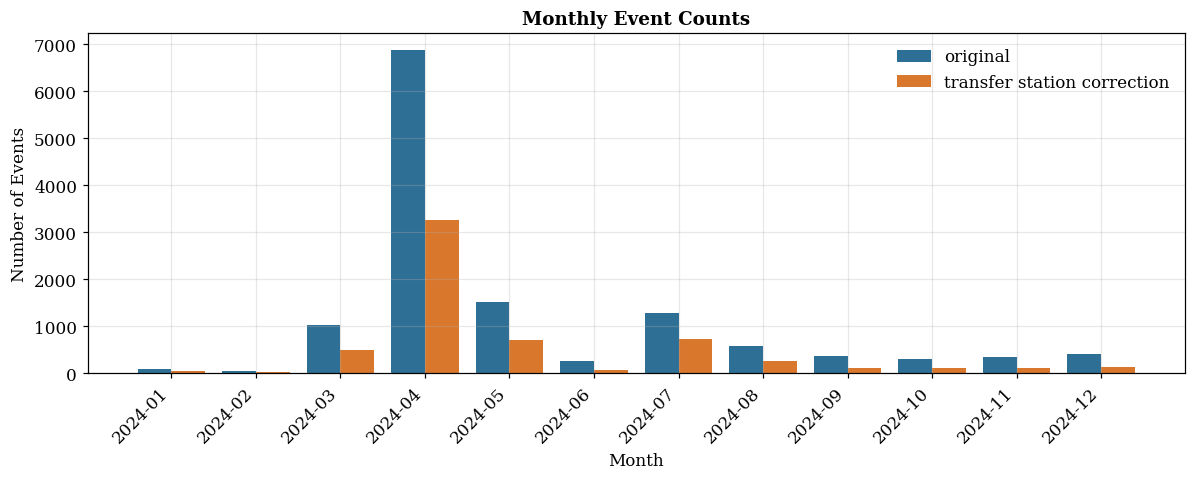

Saved: fig_monthly_event_counts.png (+ .pdf)


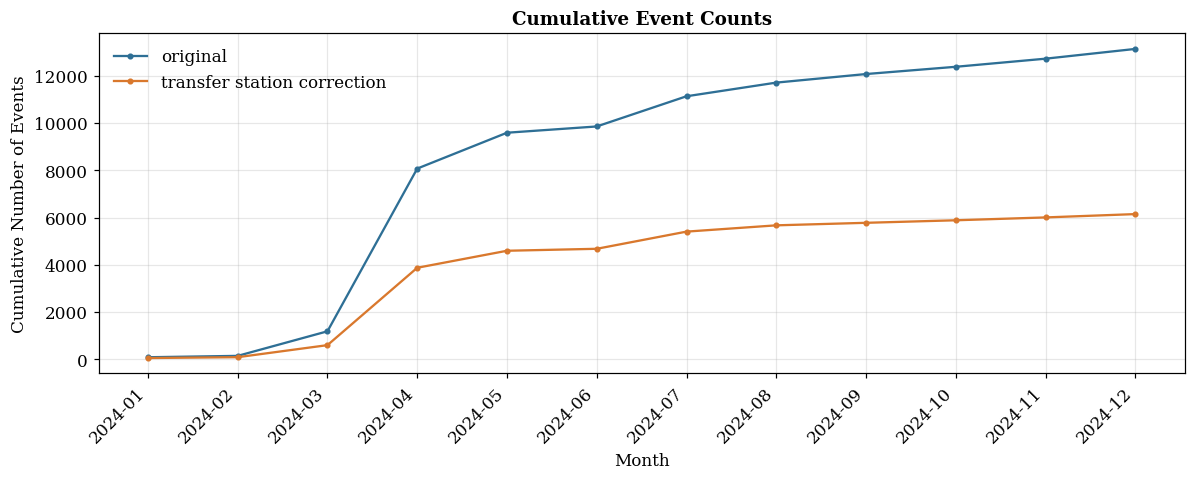

Saved: fig_cumulative_event_counts.png (+ .pdf)


In [12]:

# =========================
# 11. MONTHLY EVENT RATE PLOTS
# =========================

rate_tables = [event_rate_table(original_qc, "original")]
if transfer_qc is not None:
    rate_tables.append(event_rate_table(transfer_qc, "transfer_station_correction"))

rate_tables = [t for t in rate_tables if not t.empty]

if not rate_tables:
    raise ValueError(
        "No monthly event-rate table could be created. Check that the 'time' column "
        "was parsed correctly in section 5, and that STUDY_YEAR did not remove all rows."
    )

rate = rate_tables[0]
for t in rate_tables[1:]:
    rate = rate.merge(t, on="month", how="outer")
rate = rate.fillna(0).sort_values("month").reset_index(drop=True)
rate.to_csv(OUTPUT_DIR / "monthly_event_counts.csv", index=False)
display(rate)

# --- Monthly bar plot -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.5))
month_labels = rate["month"]
n_series = [c for c in rate.columns if c != "month"]
width = 0.8 / max(len(n_series), 1)
x = np.arange(len(rate))
for i, col in enumerate(n_series):
    ax.bar(x + i * width, rate[col], width=width, label=col.replace("_", " "),
           color=CATALOG_COLORS.get(col, None))
ax.set_xticks(x + width * (len(n_series) - 1) / 2)
ax.set_xticklabels(month_labels, rotation=45, ha="right")
ax.set_title("Monthly Event Counts")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Events")
ax.legend()
savefig("fig_monthly_event_counts")

# --- Cumulative event-count plot -------------------------------------------------------------
cumulative = rate.copy()
for col in n_series:
    cumulative[col] = cumulative[col].cumsum()

fig, ax = plt.subplots(figsize=(11, 4.5))
for col in n_series:
    ax.plot(cumulative["month"], cumulative[col], marker="o", markersize=3,
             label=col.replace("_", " "), color=CATALOG_COLORS.get(col, None))
ax.set_title("Cumulative Event Counts")
ax.set_xlabel("Month")
ax.set_ylabel("Cumulative Number of Events")
plt.xticks(rotation=45, ha="right")
ax.legend()
savefig("fig_cumulative_event_counts")

## 12. Quality-indicator distributions (original vs transfer)

Overlaid histograms let you see, at a glance, whether the transfer
catalog is shifted toward better (e.g. lower RMS, higher semblance)
values than the original catalog.

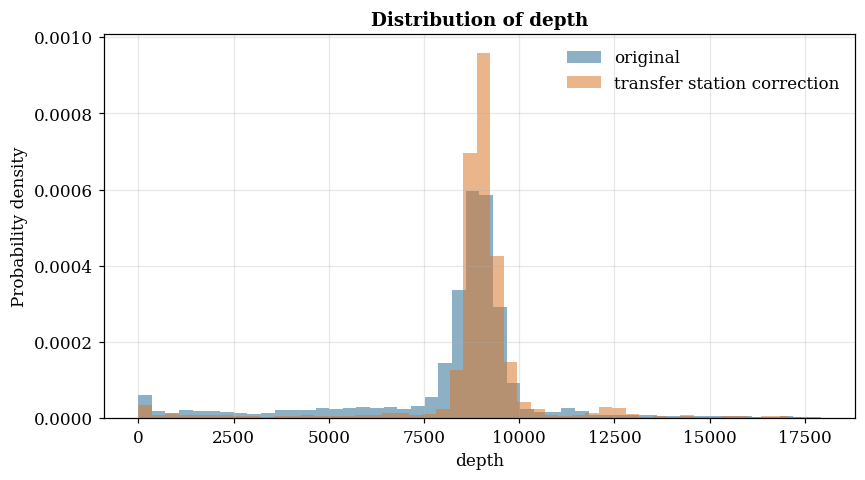

Saved: fig_hist_depth.png (+ .pdf)


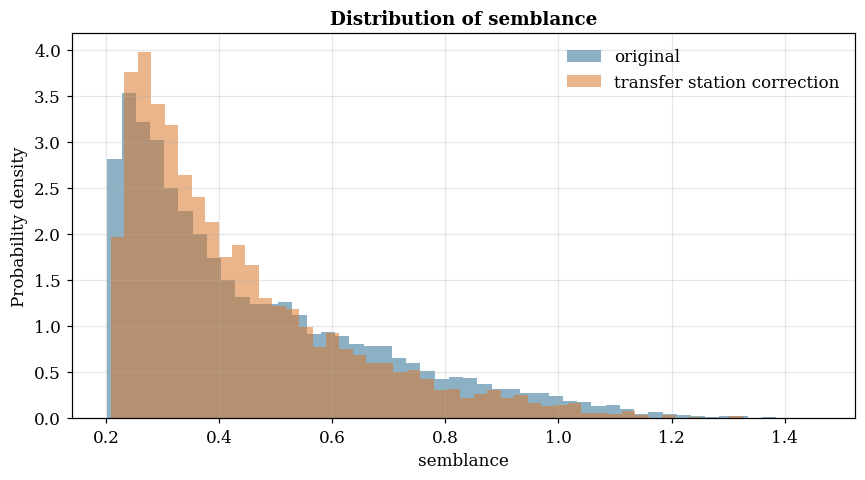

Saved: fig_hist_semblance.png (+ .pdf)


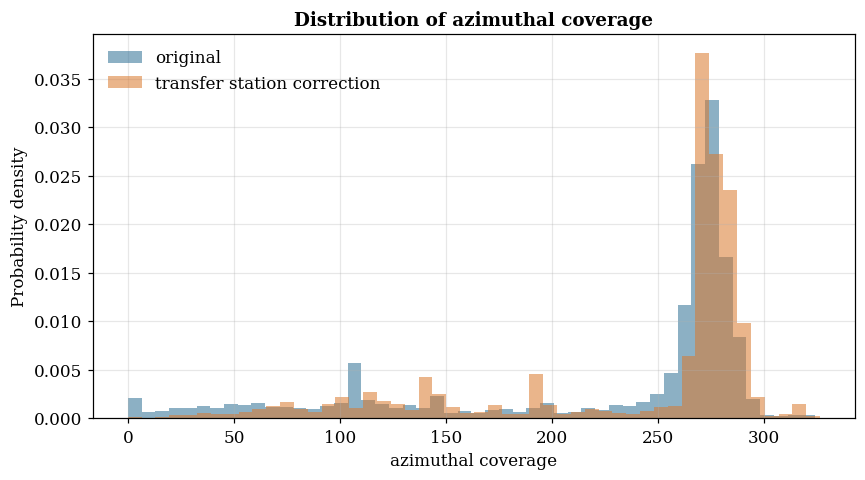

Saved: fig_hist_azimuthal_coverage.png (+ .pdf)


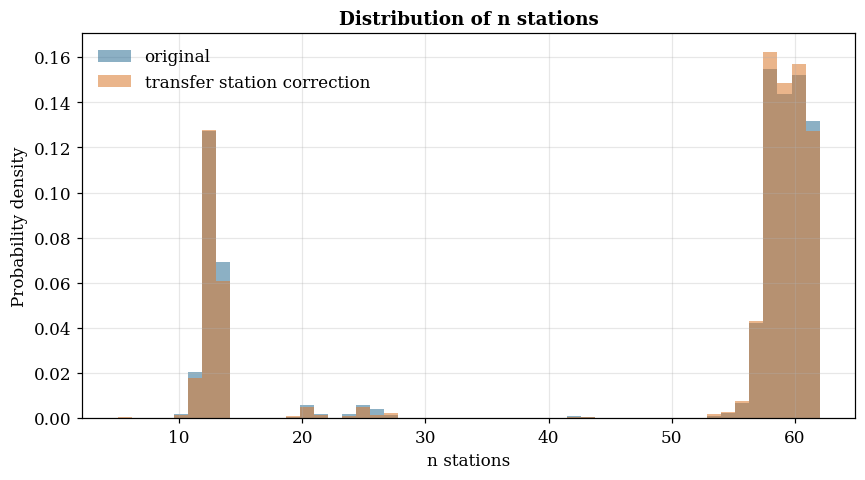

Saved: fig_hist_n_stations.png (+ .pdf)


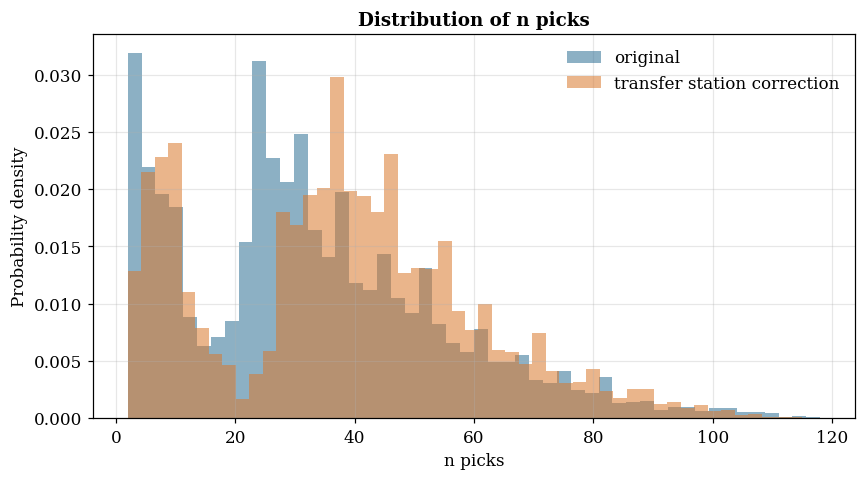

Saved: fig_hist_n_picks.png (+ .pdf)


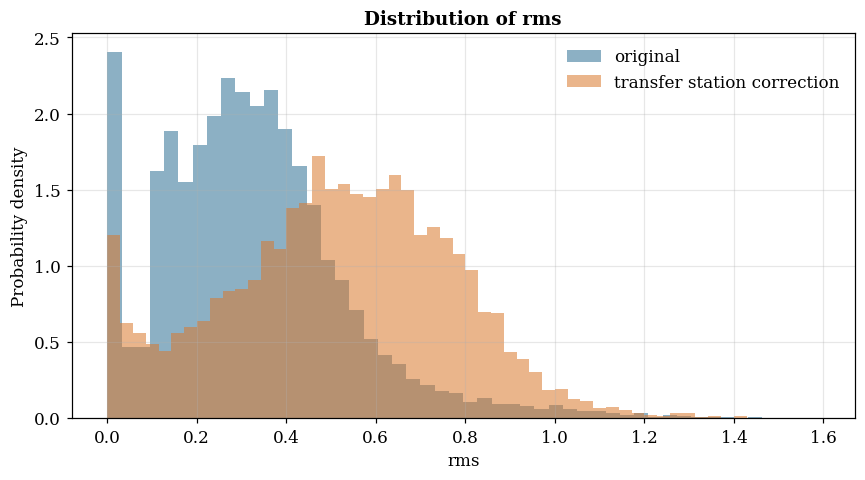

Saved: fig_hist_rms.png (+ .pdf)


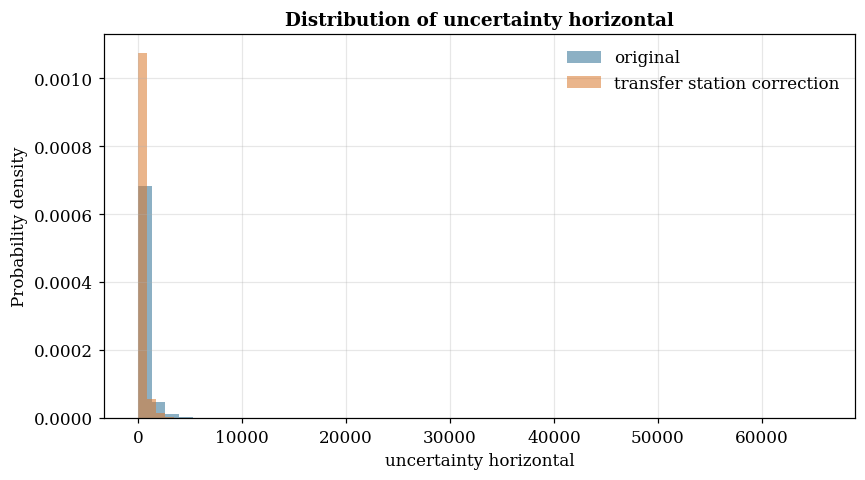

Saved: fig_hist_uncertainty_horizontal.png (+ .pdf)


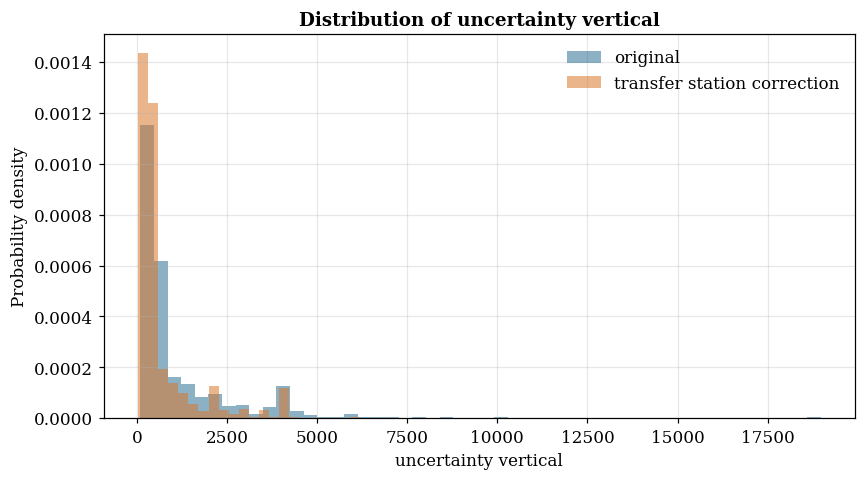

Saved: fig_hist_uncertainty_vertical.png (+ .pdf)


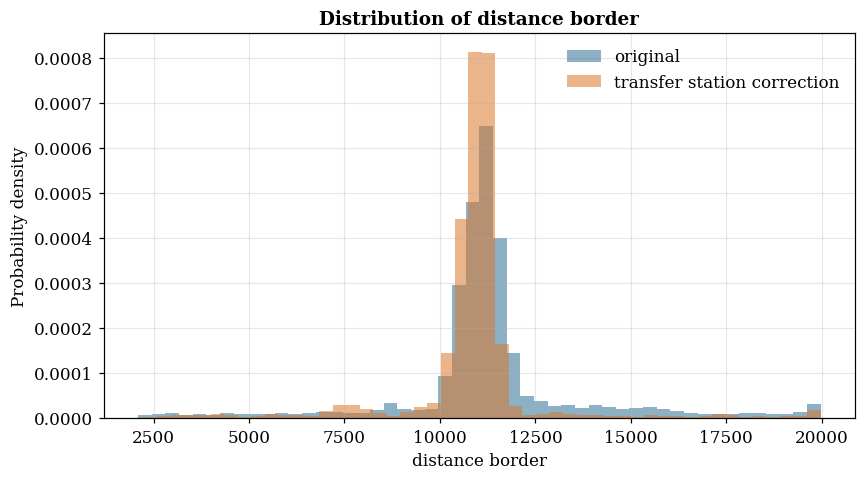

Saved: fig_hist_distance_border.png (+ .pdf)


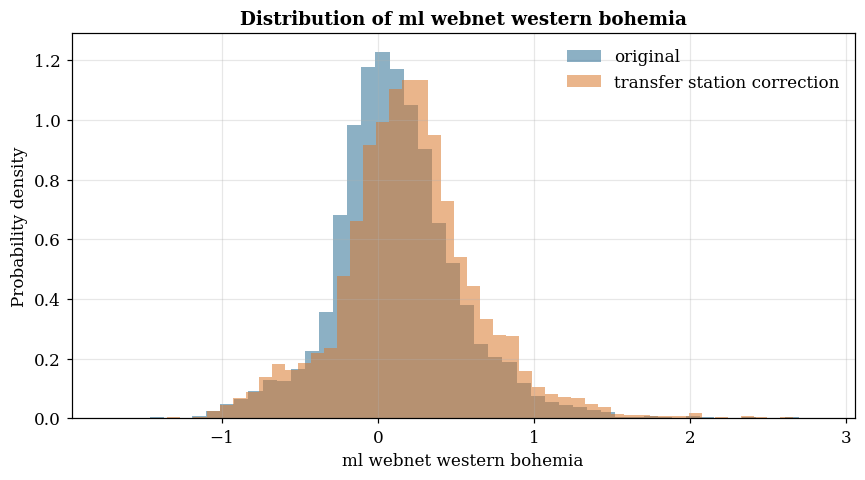

Saved: fig_hist_ml_webnet_western_bohemia.png (+ .pdf)


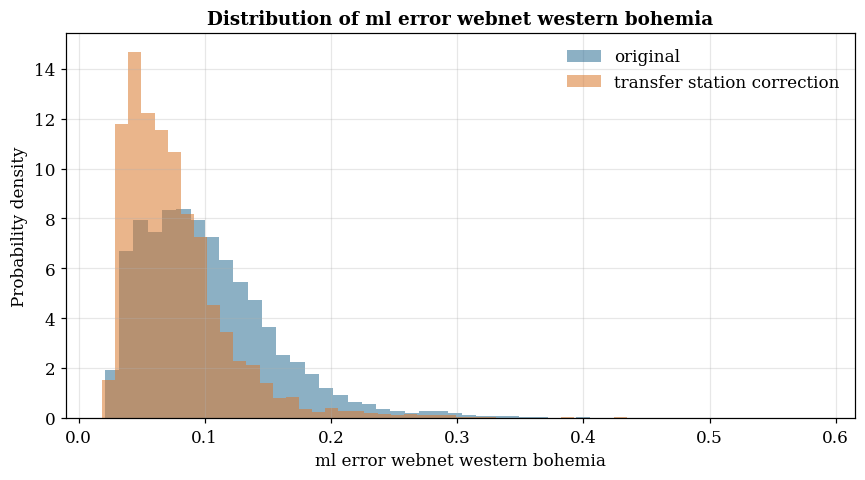

Saved: fig_hist_ml_error_webnet_western_bohemia.png (+ .pdf)


In [13]:

# =========================
# 12. DISTRIBUTION PLOTS
# =========================

plot_cols = [
    "depth", "semblance", "azimuthal_coverage", "n_stations", "n_picks", "rms",
    "uncertainty_horizontal", "uncertainty_vertical", "distance_border",
    "ml_webnet_western_bohemia", "ml_error_webnet_western_bohemia",
]

catalogs_for_plot = [("original", original_qc)]
if transfer_qc is not None:
    catalogs_for_plot.append(("transfer_station_correction", transfer_qc))

for col in plot_cols:
    if not any(col in df.columns and df[col].notna().any() for _, df in catalogs_for_plot):
        continue

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, df in catalogs_for_plot:
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                ax.hist(data, bins=50, alpha=0.55, label=label.replace("_", " "),
                        color=CATALOG_COLORS.get(label, None), density=True)
    ax.set_title(f"Distribution of {col.replace('_', ' ')}")
    ax.set_xlabel(col.replace("_", " "))
    ax.set_ylabel("Probability density")
    ax.legend()
    savefig(f"fig_hist_{col}")

## 13. Spatial distribution of detections and stations

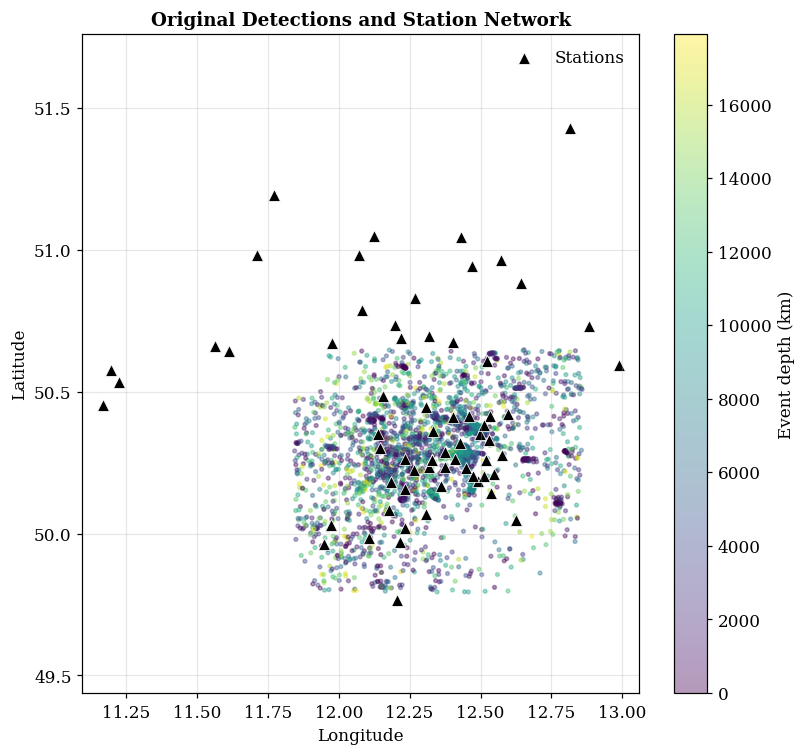

Saved: fig_map_original.png (+ .pdf)


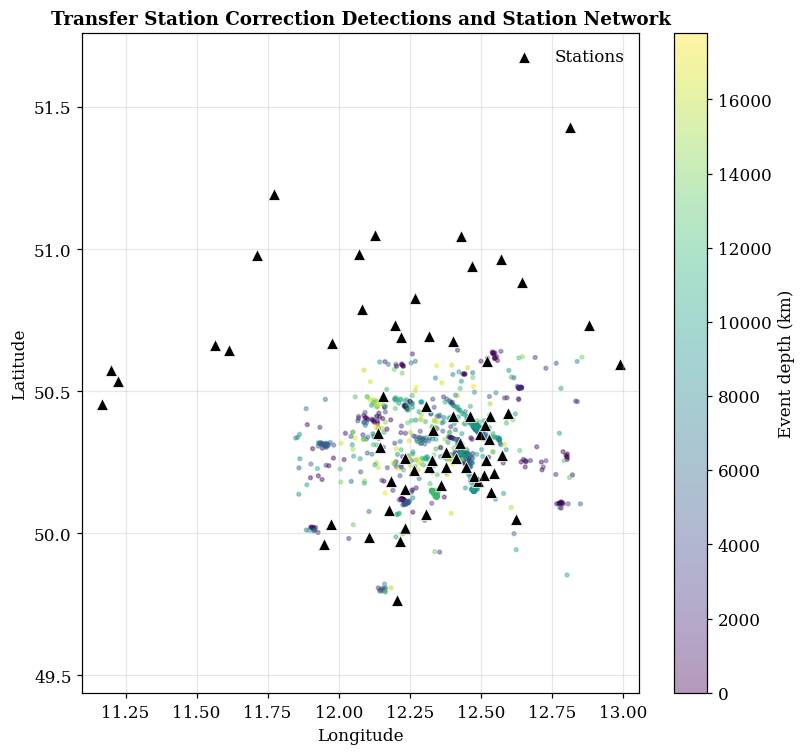

Saved: fig_map_transfer.png (+ .pdf)


In [14]:

# =========================
# 13. MAP PLOTS: STATIONS AND DETECTIONS
# =========================

def sample_for_map(df, max_points=MAX_POINTS_ON_MAP):
    return df if len(df) <= max_points else df.sample(max_points, random_state=42)


def plot_catalog_map(df, label, filename):
    fig, ax = plt.subplots(figsize=(7.5, 7))
    dmap = sample_for_map(df)
    if "depth" in dmap.columns and dmap["depth"].notna().any():
        sc = ax.scatter(dmap["lon"], dmap["lat"], s=6, alpha=0.4, c=dmap["depth"], cmap="viridis")
        plt.colorbar(sc, ax=ax, label="Event depth (km)")
    else:
        ax.scatter(dmap["lon"], dmap["lat"], s=6, alpha=0.4,
                   color=CATALOG_COLORS.get(label, "gray"), label=label.replace("_", " "))
    ax.scatter(stations["longitude"], stations["latitude"], marker="^", s=60,
               color="black", edgecolor="white", linewidth=0.5, label="Stations")
    ax.set_title(f"{label.replace('_', ' ').title()} Detections and Station Network")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc="upper right")
    ax.set_aspect("equal", adjustable="datalim")
    savefig(filename)


plot_catalog_map(original_qc, "original", "fig_map_original")
if transfer_qc is not None:
    plot_catalog_map(transfer_qc, "transfer_station_correction", "fig_map_transfer")

## 14. Depth cross-sections

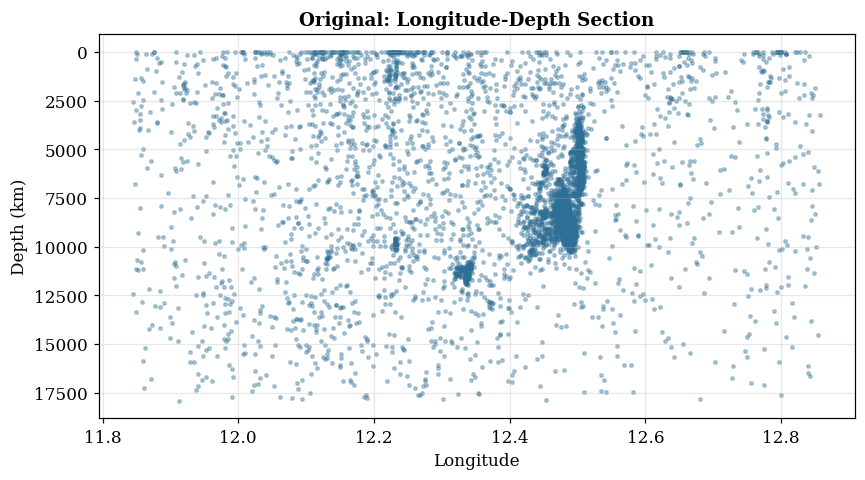

Saved: fig_cross_section_lon_depth_original.png (+ .pdf)


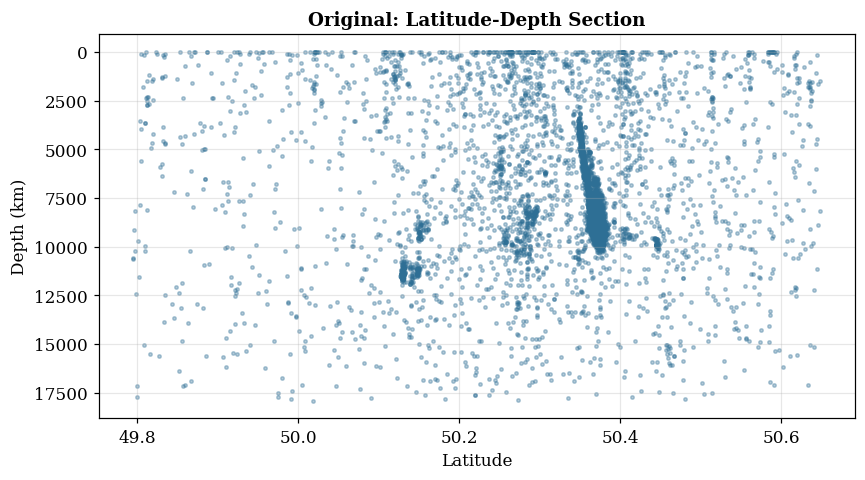

Saved: fig_cross_section_lat_depth_original.png (+ .pdf)


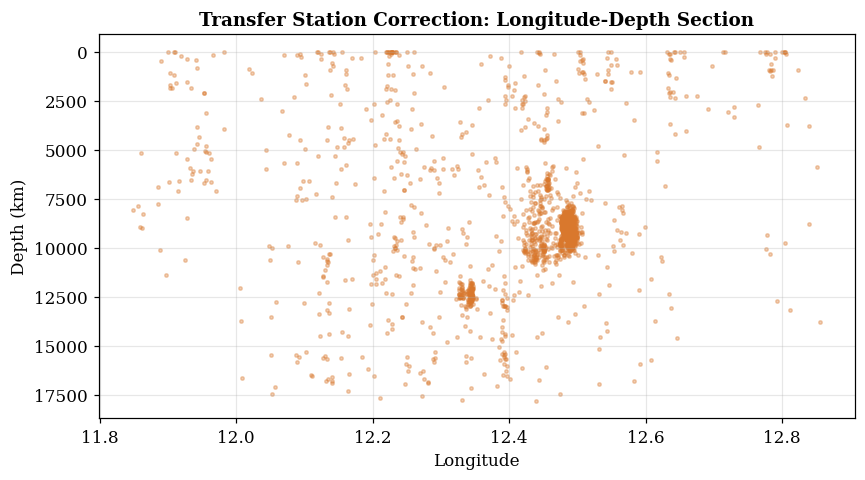

Saved: fig_cross_section_lon_depth_transfer_station_correction.png (+ .pdf)


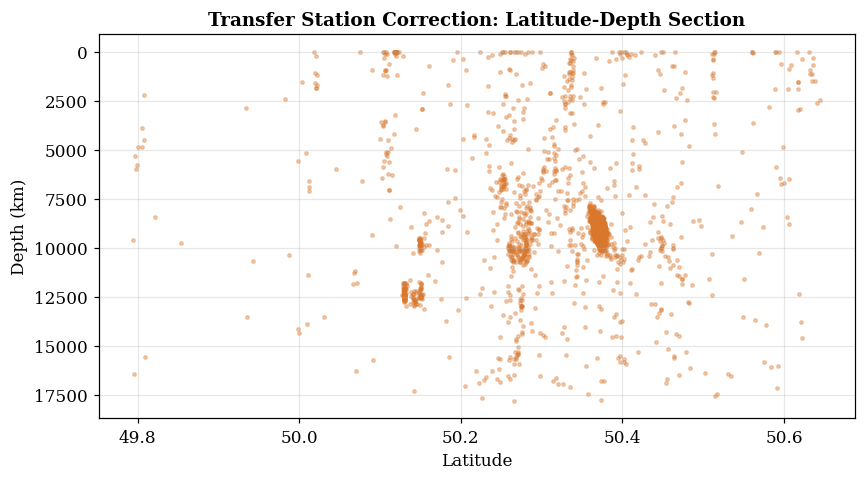

Saved: fig_cross_section_lat_depth_transfer_station_correction.png (+ .pdf)


In [15]:

# =========================
# 14. DEPTH CROSS-SECTIONS
# =========================

def plot_depth_sections(df, label):
    if not {"lat", "lon", "depth"}.issubset(df.columns):
        return

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.scatter(df["lon"], df["depth"], s=5, alpha=0.35, color=CATALOG_COLORS.get(label, None))
    ax.invert_yaxis()
    ax.set_title(f"{label.replace('_', ' ').title()}: Longitude-Depth Section")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Depth (km)")
    savefig(f"fig_cross_section_lon_depth_{label}")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.scatter(df["lat"], df["depth"], s=5, alpha=0.35, color=CATALOG_COLORS.get(label, None))
    ax.invert_yaxis()
    ax.set_title(f"{label.replace('_', ' ').title()}: Latitude-Depth Section")
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Depth (km)")
    savefig(f"fig_cross_section_lat_depth_{label}")


plot_depth_sections(original_qc, "original")
if transfer_qc is not None:
    plot_depth_sections(transfer_qc, "transfer_station_correction")

## 15. Magnitude-frequency distribution and quick magnitude-of-completeness estimate

The maximum-curvature estimate below is a fast diagnostic; for the
thesis, cross-check it with a formal Mc method (e.g. goodness-of-fit or
b-value stability) if magnitude of completeness is a key argument.

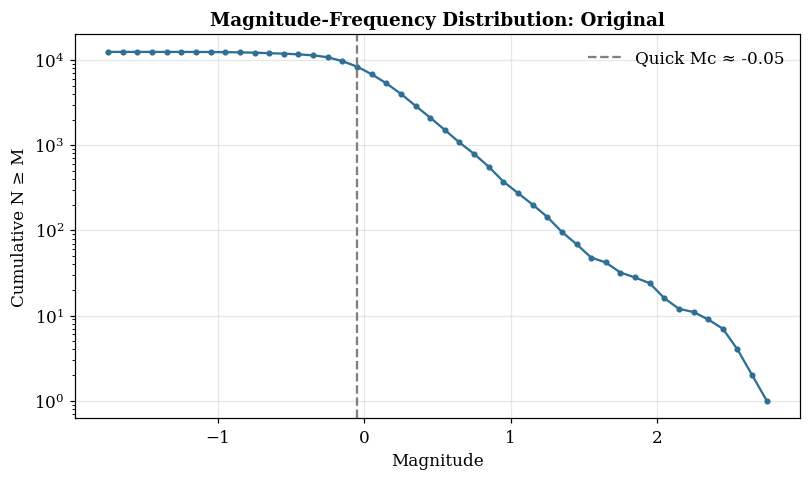

Saved: fig_magnitude_frequency_original.png (+ .pdf)


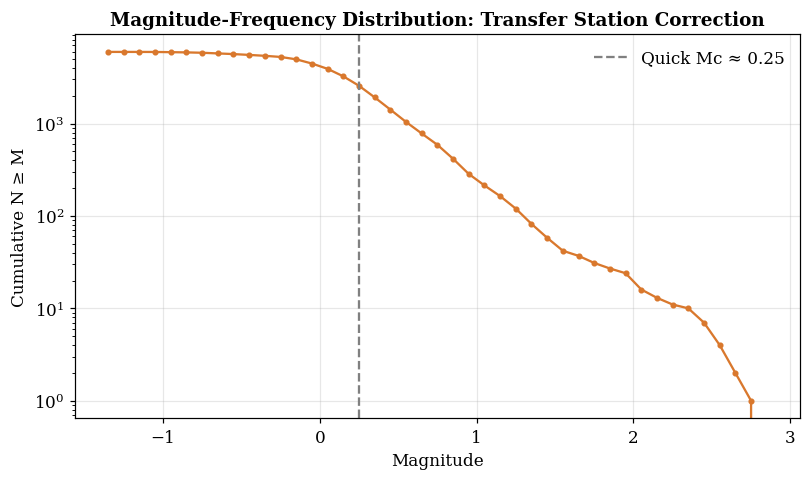

Saved: fig_magnitude_frequency_transfer_station_correction.png (+ .pdf)


,catalog,mc_max_curvature_quick_estimate,n_magnitude_values
0,original,-0.05,12461
1,transfer_station_correction,0.25,5966


In [16]:

# =========================
# 15. MAGNITUDE-FREQUENCY DIAGNOSTIC
# =========================

mag_col = "ml_webnet_western_bohemia"
mc_rows = []

for label, df in catalogs_for_plot:
    if mag_col in df.columns and df[mag_col].notna().sum() > 20:
        mc, mfd = max_curvature_mc(df[mag_col], bin_width=0.1)
        mfd.to_csv(OUTPUT_DIR / f"magnitude_frequency_{label}.csv", index=False)
        mc_rows.append({"catalog": label, "mc_max_curvature_quick_estimate": mc,
                         "n_magnitude_values": int(df[mag_col].notna().sum())})

        fig, ax = plt.subplots(figsize=(7.5, 4.5))
        ax.plot(mfd["magnitude_bin"], mfd["cumulative_n_ge_m"], marker="o", markersize=3,
                color=CATALOG_COLORS.get(label, None))
        ax.set_yscale("log")
        ax.axvline(mc, linestyle="--", color="gray", label=f"Quick Mc \u2248 {mc:.2f}")
        ax.set_title(f"Magnitude-Frequency Distribution: {label.replace('_', ' ').title()}")
        ax.set_xlabel("Magnitude")
        ax.set_ylabel("Cumulative N \u2265 M")
        ax.legend()
        savefig(f"fig_magnitude_frequency_{label}")

mc_table = pd.DataFrame(mc_rows)
mc_table.to_csv(OUTPUT_DIR / "magnitude_completeness_quick_estimate.csv", index=False)
mc_table

## 16. Automatic, data-driven interpretation: comparing the catalogs as independent populations

This section builds the written justification for the discussion
section **without matching individual events** between catalogs. It
treats `original_qc` and `transfer_qc` as two independent samples and
asks: on every quality indicator where both catalogs have data, is the
transfer catalog systematically better, even though it has fewer
events?

For each shared quality column, the median value in the original
catalog is compared with the median value in the transfer catalog
(direction of “better” depends on the indicator, e.g. lower RMS is
better, higher semblance is better). The overall QC-pass rate of each
catalog is compared the same way. A simple score (fraction of
indicators favouring the transfer catalog) is used to phrase a
verdict, mirroring the logic thesis reviewers expect to see, but
entirely from catalog-level statistics rather than paired events.

In [17]:

# =========================
# 16. CATALOG-LEVEL (NO-MATCHING) INTERPRETATION
# =========================

# direction: "lower" = smaller is better, "higher" = larger is better
QUALITY_DIRECTION = {
    "rms": "lower",
    "uncertainty_horizontal": "lower",
    "uncertainty_vertical": "lower",
    "semblance": "higher",
    "azimuthal_coverage": "higher",
    "n_stations": "higher",
    "n_picks": "higher",
    "distance_border": "higher",
    "ml_error_webnet_western_bohemia": "lower",
}

lines = []
lines.append("# Automatic Interpretation: Original vs. Transfer-Learning Catalog\n")
lines.append("(catalog-level comparison, no event matching)\n\n")

n_orig = len(original_qc)
lines.append(f"- Original catalog: **{n_orig}** raw events "
             f"({original_qc['qc_pass'].mean()*100:.1f}% pass QC).\n")

if transfer_qc is not None:
    n_trans = len(transfer_qc)
    pct_reduction = 100 * (n_orig - n_trans) / n_orig if n_orig else np.nan
    lines.append(f"- Transfer catalog: **{n_trans}** raw events "
                 f"({transfer_qc['qc_pass'].mean()*100:.1f}% pass QC), "
                 f"a {pct_reduction:.1f}% reduction in raw event count "
                 "relative to the original catalog.\n\n")

    lines.append("## 1. QC pass-rate comparison\n\n")
    qc_pass_orig = original_qc["qc_pass"].mean() * 100
    qc_pass_trans = transfer_qc["qc_pass"].mean() * 100
    lines.append(f"- Original catalog QC-pass rate: {qc_pass_orig:.1f}%\n")
    lines.append(f"- Transfer catalog QC-pass rate: {qc_pass_trans:.1f}%\n\n")

    lines.append("## 2. Quality-indicator medians (independent samples)\n\n")
    score_total, score_improved = 0, 0
    for col, direction in QUALITY_DIRECTION.items():
        if col not in original_qc.columns or col not in transfer_qc.columns:
            continue
        orig_vals = original_qc[col].dropna()
        trans_vals = transfer_qc[col].dropna()
        if len(orig_vals) == 0 or len(trans_vals) == 0:
            continue
        m_orig, m_trans = orig_vals.median(), trans_vals.median()
        transfer_is_better = (direction == "lower" and m_trans < m_orig) or \
                              (direction == "higher" and m_trans > m_orig)
        score_total += 1
        score_improved += int(transfer_is_better)
        lines.append(
            f"- **{col}**: original median = {m_orig:.4g}, transfer median = {m_trans:.4g} "
            f"-> transfer catalog is "
            f"{'BETTER' if transfer_is_better else 'similar/worse'} on this indicator.\n"
        )

    verdict_score = score_improved / score_total if score_total else np.nan
    lines.append(f"\n## 3. Overall quantitative verdict\n\n")
    lines.append(f"{score_improved} of {score_total} independent quality indicators "
                 f"({100*verdict_score:.0f}%) favour the transfer catalog.\n\n")

    if score_total == 0:
        verdict = ("Not enough overlapping quality columns were available between the two "
                   "catalogs to compute a quantitative verdict.")
    elif verdict_score >= 0.65:
        verdict = (
            f"The transfer-learning model with SimpleStationCorrection detects {pct_reduction:.1f}% "
            "fewer events than the original model, yet the majority of independent quality "
            "indicators (e.g. RMS, location uncertainty, semblance, station/pick support) are "
            "better in the transfer catalog, and its overall QC-pass rate is "
            f"{'higher' if qc_pass_trans > qc_pass_orig else 'comparable'}. Because these "
            "comparisons are made on the two catalogs as independent populations, without "
            "matching specific events, this does not prove that every removed detection was a "
            "false positive; however, it is consistent with the smaller catalog size reflecting "
            "a more conservative, higher-precision detector rather than a general loss of "
            "sensitivity."
        )
    elif verdict_score <= 0.35:
        verdict = (
            f"The transfer-learning model detects {pct_reduction:.1f}% fewer events than the "
            "original model, but most independent quality indicators do not show a systematic "
            "improvement in the transfer catalog. This pattern is more consistent with reduced "
            "recall (fewer events detected overall, without a clear quality trade-off) than with "
            "a precision gain."
        )
    else:
        verdict = (
            f"The transfer-learning model detects {pct_reduction:.1f}% fewer events than the "
            "original model. The evidence from independent-population comparisons is mixed: "
            "roughly half of the quality indicators favour the transfer catalog and half do not. "
            "This is consistent with a moderate precision/recall trade-off rather than a "
            "clear-cut improvement, and framing the smaller catalog as strictly \"better\" should "
            "be qualified accordingly."
        )
    lines.append(verdict + "\n")
else:
    lines.append("\nNo transfer catalog was provided, so no original-vs-transfer comparison "
                 "could be made.\n")

interpretation_text = "".join(lines)
summary_path = OUTPUT_DIR / "analysis_interpretation_summary_no_matching.md"
summary_path.write_text(interpretation_text, encoding="utf-8")

print(interpretation_text)
print("\nSaved:", summary_path)

# Automatic Interpretation: Original vs. Transfer-Learning Catalog
(catalog-level comparison, no event matching)

- Original catalog: **13281** raw events (0.1% pass QC).
- Transfer catalog: **6233** raw events (0.1% pass QC), a 53.1% reduction in raw event count relative to the original catalog.

## 1. QC pass-rate comparison

- Original catalog QC-pass rate: 0.1%
- Transfer catalog QC-pass rate: 0.1%

## 2. Quality-indicator medians (independent samples)

- **rms**: original median = 0.3052, transfer median = 0.5276 -> transfer catalog is similar/worse on this indicator.
- **uncertainty_horizontal**: original median = 182.2, transfer median = 98.82 -> transfer catalog is BETTER on this indicator.
- **uncertainty_vertical**: original median = 531.2, transfer median = 312.5 -> transfer catalog is BETTER on this indicator.
- **semblance**: original median = 0.3863, transfer median = 0.3718 -> transfer catalog is similar/worse on this indicator.
- **azimuthal_coverage**: original median 

## 17. Export combined, thesis-ready output tables

In [ ]:

# =========================
# 17. EXPORT FINAL CLEAN TABLES
# =========================

combined = original_qc.copy()
if transfer_qc is not None:
    combined = pd.concat([combined, transfer_qc], ignore_index=True)
combined.to_csv(OUTPUT_DIR / "combined_catalog_with_qc.csv", index=False)

catalog_summary_table.to_csv(OUTPUT_DIR / "final_catalog_summary_table.csv", index=False)
qc_report.to_csv(OUTPUT_DIR / "final_qc_report.csv", index=False)

print("All outputs saved to:", OUTPUT_DIR.resolve())
print("\nMain output files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p.name)

## Using these results in the thesis

**Key output files**

| File                                             | Use                                 |
|:------------------------------------------|:---------------------------|
| `catalog_summary.csv`                            | Headline table: raw vs. QC-pass     
                                                    counts and median quality            
                                                    indicators per catalog               |
| `qc_summary.csv`                                 | Pass/fail rate for every individual 
                                                    QC check, per catalog                |
| `analysis_interpretation_summary_no_matching.md` | Automatically generated,            
                                                    quantitative verdict text (no        
                                                    event matching)                      |
| `fig_*.png` / `fig_*.pdf`                        | All figures, in both raster and     
                                                    vector form, ready for direct        
                                                    thesis inclusion                     |

**Suggested thesis wording (adapt to your actual computed numbers from
Section 16):**

> The original Qseek model produced a substantially larger detection
> catalog than the transfer-learning model with SimpleStationCorrection.
> This difference in event count was not treated as evidence of relative
> catalog quality by itself. Instead, both catalogs were evaluated as
> independent populations using structural and seismological
> quality-control indicators -- RMS residual, station and pick support,
> semblance, azimuthal coverage, horizontal and vertical location
> uncertainty, distance from the search-volume border, and magnitude
> distribution. \[Insert the automatically generated verdict and
> specific percentages from `analysis_interpretation_summary_no_matching.md`
> here.\]

Adjust the QC thresholds in Section 1 once you have confirmed the
correct units and typical value ranges for your specific Qseek
configuration, then re-run the notebook -- every downstream table,
figure, and the automatic verdict will update accordingly.